# Домашнее задание -- Занятие 29-30: Сверточные нейронные сети (CNN)

Цель: закрепить понимание сверток, pooling, формулы размеров и научиться строить CNN в PyTorch.

---

## Часть 1 -- Теория

Ответьте на вопросы текстом в markdown-ячейках.

**1.1** Объясните своими словами: чем сверточный слой отличается от полносвязного? Почему для картинок используют именно свертки?

*Ваш ответ:*
Полносвязный слой пытается выучить всю картинку целиком, для этого нужно много памяти, если объект чуть-чуть сдвинется, то получается ошибка. Сверточный слой вместо этого использует маленькое скользящее окно, которое ищет конкретные детали в любой части кадра. Это делает нейросеть намного быстрее и позволяет ей узнавать объекты, даже если они расположены не в центре


**1.2** Что такое:
- фильтр (kernel)
- stride
- padding
- feature map

Для каждого термина напишите определение и приведите пример.

*Ваш ответ:*
- Фильтр (kernel): Маленькая матрица (например, 3x3), которая скользит по картинке и ищет признаки. Пример: фильтр для поиска вертикальных линий.
- Stride (шаг): На сколько пикселей сдвигается фильтр за один раз. Пример: шаг 2 заставляет фильтр прыгать через один пиксель, уменьшая размер вдвое.
- Padding (отступ): Добавление пустых рамок (нулей) по краям картинки. Пример: паддинг в 1 пиксель позволяет сохранить исходный размер картинки после свертки.
- Feature map (карта признаков): Результат работы фильтра. Это "новая картинка", где ярко подсвечены места, где фильтр нашел то, что искал.

**1.3** Рассчитайте выходной размер (высота x ширина) после свертки. Покажите вычисления.

Формула: `Output = (N - F + 2P) / S + 1`

a) Вход: 32x32, Kernel: 5x5, Padding: 0, Stride: 1

b) Вход: 28x28, Kernel: 3x3, Padding: 1, Stride: 2

c) Вход: 64x64, Kernel: 5x5, Padding: 2, Stride: 1

*Ваш ответ:*
- a) (32 - 5 + 0) / 1 + 1 = 28x28
- b) (28 - 3 + 2*1) / 2 + 1 = (27/2) + 1 = 13.5 + 1 = 14x14
- c) (64 - 5 + 2*2) / 1 + 1 = 64x64


---

## Часть 2 -- Свертка и pooling руками

Загрузите одно изображение из MNIST. Примените к нему фильтр и Max Pooling. Визуализируйте каждый этап.

In [1]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d

torch.manual_seed(42)
np.random.seed(42)

**2.1** Загрузите любую картинку из MNIST (не обязательно первую). Выведите её и напечатайте форму массива.

Форма массива: (28, 28)


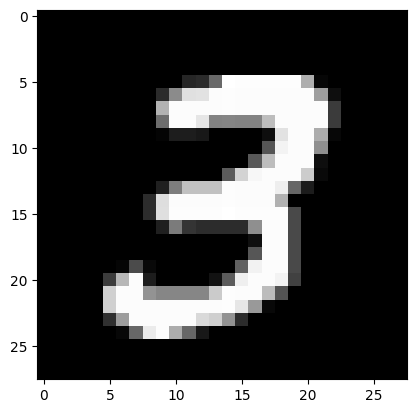

In [3]:
# Ваш код здесь
dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True)
img, label = dataset[7]
img_np = np.array(img)

print(f"Форма массива: {img_np.shape}")
plt.imshow(img_np, cmap='gray')
plt.show()

**2.2** Определите два фильтра: Sobel X и Edge Detection. Примените оба к картинке через `scipy.signal.convolve2d` с `mode='valid'`. Визуализируйте три картинки рядом: оригинал, результат Sobel X, результат Edge Detection.

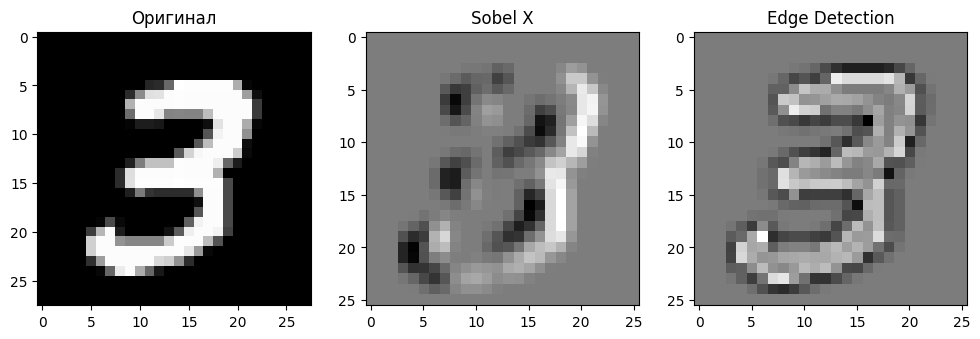

In [4]:
# Sobel X
sobel_x = np.array([[-1, 0, 1],
                     [-2, 0, 2],
                     [-1, 0, 1]])

# Edge Detection
edge = np.array([[-1, -1, -1],
                  [-1,  8, -1],
                  [-1, -1, -1]])

# Ваш код здесь
res_sobel = convolve2d(img_np, sobel_x, mode='valid')
res_edge = convolve2d(img_np, edge, mode='valid')

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(img_np, cmap='gray'); ax[0].set_title("Оригинал")
ax[1].imshow(res_sobel, cmap='gray'); ax[1].set_title("Sobel X")
ax[2].imshow(res_edge, cmap='gray'); ax[2].set_title("Edge Detection")
plt.show()


**2.3** Напишите функцию Max Pooling (size=2, stride=2) и примените к результату свертки Sobel X. Выведите размеры до и после pooling.

Размер до: (26, 26), Размер после: (13, 13)


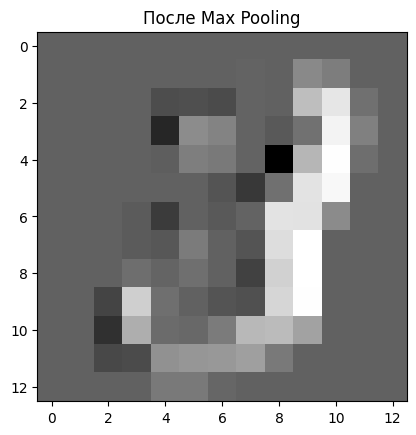

In [5]:
def max_pooling(image, size=2, stride=2):
    h, w = image.shape
    new_h, new_w = (h - size) // stride + 1, (w - size) // stride + 1
    result = np.zeros((new_h, new_w))

    for i in range(0, new_h):
        for j in range(0, new_w):
            slice_img = image[i*stride:i*stride+size, j*stride:j*stride+size]
            result[i, j] = np.max(slice_img)
    return result

pooled_img = max_pooling(res_sobel)
print(f"Размер до: {res_sobel.shape}, Размер после: {pooled_img.shape}")

plt.imshow(pooled_img, cmap='gray')
plt.title("После Max Pooling")
plt.show()

---

## Часть 3 -- Построение CNN в PyTorch

Постройте и обучите сверточную сеть на MNIST.

**3.1** Реализуйте модель `SimpleCNN` со следующей архитектурой:

```
Conv2d(1, 8, kernel_size=3, padding=1) -> ReLU -> MaxPool2d(2)
Conv2d(8, 16, kernel_size=3, padding=1) -> ReLU -> MaxPool2d(2)
Flatten -> Linear(16*7*7, 10)
```

Проверьте что размеры проходят: подайте `torch.randn(1, 1, 28, 28)` и убедитесь что выход `(1, 10)`.

In [7]:
# Ваш код здесь
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.fc = nn.Linear(16 * 7 * 7, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 7 * 7)
        return self.fc(x)

model = SimpleCNN()
test_input = torch.randn(1, 1, 28, 28)
print(f"Выходной размер: {model(test_input).shape}")


Выходной размер: torch.Size([1, 10])


**3.2** Загрузите MNIST, создайте DataLoader (batch_size=64). Обучите модель на 3 эпохи с Adam (lr=0.001) и CrossEntropyLoss. Выведите loss и accuracy после каждой эпохи.

In [8]:
# Ваш код здесь
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

transform = transforms.ToTensor()
train_loader = DataLoader(datasets.MNIST('./data', train=True, download=True, transform=transform), batch_size=64, shuffle=True)

optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

for epoch in range(3):
    total_loss = 0
    correct = 0
    for images, labels in train_loader:
        optimizer.zero_grad()
        output = model(images)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (output.argmax(1) == labels).sum().item()

    print(f"Эпоха {epoch+1}: Loss = {total_loss/len(train_loader):.4f}, Acc = {correct/60000:.4f}")

Эпоха 1: Loss = 0.3264, Acc = 0.9057
Эпоха 2: Loss = 0.0878, Acc = 0.9737
Эпоха 3: Loss = 0.0674, Acc = 0.9795


**3.3** Визуализируйте feature maps: прогоните одну картинку через первый сверточный слой и покажите все 8 карт признаков.

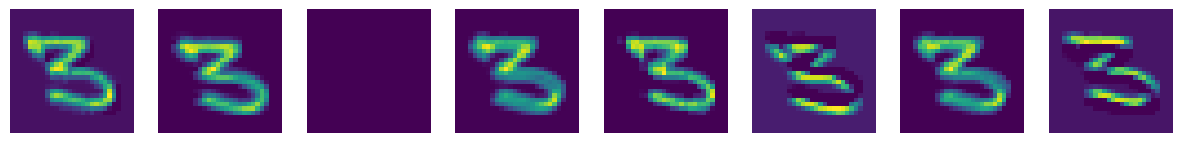

In [9]:
# Ваш код здесь
img_test, _ = next(iter(train_loader))
img_test = img_test[0:1]

with torch.no_grad():
    features = F.relu(model.conv1(img_test))

fig, axes = plt.subplots(1, 8, figsize=(15, 2))
for i in range(8):
    axes[i].imshow(features[0, i].cpu().numpy(), cmap='viridis')
    axes[i].axis('off')
plt.show()

**3.4** Измените архитектуру: поставьте `kernel_size=5, padding=2` вместо `kernel_size=3, padding=1`. Обучите заново на 3 эпохи. Сравните accuracy с оригинальной моделью.

In [10]:
# Ваш код здесь
class SimpleCNN_v2(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=5, padding=2)
        self.pool = nn.MaxPool2d(2)
        self.fc = nn.Linear(16 * 7 * 7, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(-1, 16 * 7 * 7)
        return self.fc(x)

model_v2 = SimpleCNN_v2()
optimizer_v2 = torch.optim.Adam(model_v2.parameters(), lr=0.001)

print("Обучение модели v2 (Kernel 5x5):")
for epoch in range(3):
    total_loss = 0
    correct = 0
    for images, labels in train_loader:
        optimizer_v2.zero_grad()
        output = model_v2(images)
        loss = criterion(output, labels)
        loss.backward()
        optimizer_v2.step()

        total_loss += loss.item()
        correct += (output.argmax(1) == labels).sum().item()

    accuracy = correct / len(train_loader.dataset)
    print(f"Эпоха {epoch+1}: Loss = {total_loss/len(train_loader):.4f}, Accuracy = {accuracy:.4f}")

Обучение модели v2 (Kernel 5x5):
Эпоха 1: Loss = 0.2633, Accuracy = 0.9223
Эпоха 2: Loss = 0.0803, Accuracy = 0.9756
Эпоха 3: Loss = 0.0590, Accuracy = 0.9820


---

## Часть 4 -- Объяснение архитектуры

**4.1** Для модели SimpleCNN из части 3.1 напишите: что делает каждый слой, зачем он нужен, и как меняется размер данных. Заполните таблицу:

| Слой | Что делает | Размер до | Размер после |
|------|-----------|-----------|-------------|
| Conv2d(1,8,3,pad=1) | ? | 28x28x1 | ? |
| ReLU | ? | ? | ? |
| MaxPool2d(2) | ? | ? | ? |
| Conv2d(8,16,3,pad=1) | ? | ? | ? |
| ReLU | ? | ? | ? |
| MaxPool2d(2) | ? | ? | ? |
| Flatten | ? | ? | ? |
| Linear(784, 10) | ? | ? | ? |

*Ваш ответ (заполните таблицу):*
- Conv2d(1, 8, 3, pad=1) — Ищет 8 простых признаков (линии и углы), размер до: 28x28x1, после: 28x28x8
- ReLU — Убирает отрицательные значения, оставляя только важные сигналы, размер до: 28x28x8, после: 28x28x8
- MaxPool2d(2) — Уменьшает картинку в два раза, выбирая самые яркие пиксели, размер до: 28x28x8, после: 14x14x8
- Conv2d(8, 16, 3, pad=1) — Ищет 16 более сложных сочетаний признаков, размер до: 14x14x8, после: 14x14x16
- ReLU — Снова активирует только нужные нейроны, размер до: 14x14x16, после: 14x14x16
- MaxPool2d(2) — Еще раз уменьшает размер для упрощения данных, размер до: 14x14x16, после: 7x7x16
- Flatten — Вытягивает многомерную карту признаков в одну длинную линию, размер до: 7x7x16, после: 784
- Linear(784, 10) — Сравнивает полученные признаки и выдает ответ (какая это цифра), размер до: 784, после: 10

---

## Бонус -- Свое изображение

Загрузите любую картинку (фото, скриншот), преобразуйте в черно-белое 28x28, примените свертку и pooling. Визуализируйте результат.

In [ ]:
# Подсказка:
# from PIL import Image
# img = Image.open('your_image.jpg').convert('L').resize((28, 28))
# img_np = np.array(img) / 255.0

# Ваш код здесь
